# Quản lý dữ liệu kiểm thử cho ứng dụng cơ sở dữ liệu

Notebook này minh họa đề tài: **Quản lý dữ liệu kiểm thử cho ứng dụng cơ sở dữ liệu**.

Nội dung chính:

1. Seed data  
2. Synthetic user  
3. Refresh dữ liệu kiểm thử  
4. Bảo vệ dữ liệu cá nhân  

Đề tài yêu cầu đề xuất chiến lược Seed Data, Synthetic User, Refresh Data và bảo vệ dữ liệu cá nhân cho ứng dụng cơ sở dữ liệu. Trong phần thực nghiệm em đã xây dựng một hệ thống bán hàng mô phỏng, triển khai đầy đủ bốn chiến lược này bằng Python Notebook. Kết quả tạo được bộ Seed Data chuẩn, 500 Synthetic User, quy trình Refresh Data có kiểm tra toàn vẹn dữ liệu và cơ chế Data Masking giúp loại bỏ 100% dữ liệu nhạy cảm khỏi môi trường kiểm thử. Đồng thời em cũng xác định các QA Control Points tương ứng cho từng chiến lược theo đúng yêu cầu của đề tài

**Mục đích:** Thiết lập thư viện và hàm tiện ích dùng trong toàn notebook.

**Thuật toán:**
1. Import các thư viện (`random`, `string`, `pandas`, `numpy`, `matplotlib`, ...) .
2. Cấu hình hiển thị của `pandas` để xem dữ liệu rõ hơn.
3. Tạo thư mục `data/` và `outputs_notebook/` nếu chưa tồn tại.
4. Thiết lập seed ngẫu nhiên cho `random` và `numpy` để tái lập kết quả.
5. Định nghĩa hàm `xuat_csv` để xuất `DataFrame` ra CSV trong `outputs_notebook`.
6. Định nghĩa hàm `save_bar_chart` để lưu biểu đồ cột và hiển thị trong notebook.
7. Định nghĩa hàm `tao_ma` để sinh mã định danh theo tiền tố và số.


In [33]:
# Thiết lập môi trường: import thư viện và hàm tiện ích
import random
import string
from pathlib import Path
from datetime import datetime, timedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Cấu hình hiển thị cho pandas
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.max_columns", 50)

DATA_DIR = Path("data")
OUTPUT_DIR = Path("outputs_notebook")
DATA_DIR.mkdir(exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)

# Thiết lập seed để kết quả có thể tái lập
random.seed(42)
np.random.seed(42)

# Hàm tiện ích: xuất DataFrame ra CSV trong thư mục outputs_notebook
def xuat_csv(df, file_name):
    df.to_csv(OUTPUT_DIR / file_name, index=False, encoding="utf-8-sig")

# Hàm tiện ích: lưu biểu đồ cột và hiển thị
def save_bar_chart(x, y, title, xlabel, ylabel, file_name):
    plt.figure(figsize=(9, 5))
    plt.bar(x, y)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / file_name)
    plt.show()

# Sinh mã định danh có tiền tố, ví dụ: KH0001
def tao_ma(prefix, number, width=4):
    return f"{prefix}{number:0{width}d}"

## 1. Tạo dữ liệu mô phỏng cho ứng dụng cơ sở dữ liệu

Ứng dụng minh họa là hệ thống bán hàng gồm khách hàng, sản phẩm, đơn hàng, chi tiết đơn hàng và thanh toán.

**Mục đích:** Sinh dữ liệu production mô phỏng cho các bảng chính (customers, products, orders, order_items, payments).

**Thuật toán:**
1. Khởi tạo danh sách họ, tên đệm, tên, tỉnh/thành và danh mục sản phẩm.
2. Định nghĩa hàm trợ giúp: `random_name`, `random_phone`, `random_email`, `random_cccd`.
3. Sinh 100 khách hàng: tạo mã `KH`, tên, email, điện thoại, CCCD, địa chỉ, hạng thành viên, trạng thái.
4. Sinh 30 sản phẩm: mã `SP`, tên, danh mục, giá, trạng thái.
5. Sinh 250 đơn hàng: với mỗi đơn lấy khách hàng ngẫu nhiên, chọn 1–4 sản phẩm, tính `order_items` và `payments` tương ứng.
6. Chuyển các list thành `DataFrame` cho customers, products, orders, order_items, payments.
7. Lưu các `DataFrame` ra CSV trong `data/` và hiển thị vài dòng mẫu.

In [34]:
# ============================================================
# CELL 2: SINH DỮ LIỆU PRODUCTION MÔ PHỎNG
# customers, products, orders, order_items, payments
# ============================================================

ho = ["Nguyễn", "Trần", "Lê", "Phạm", "Hoàng", "Vũ", "Đặng", "Bùi", "Đỗ", "Hồ"]
ten_dem = ["Văn", "Thị", "Minh", "Gia", "Quang", "Anh", "Tiến", "Hữu", "Thanh", "Ngọc"]
ten = ["An", "Bình", "Chi", "Dũng", "Hà", "Hải", "Lan", "Linh", "Nam", "Thắng", "Trang", "Tuấn"]

tinh_thanh = [
    "Hà Nội",
    "Thái Nguyên",
    "Vĩnh Phúc",
    "Đà Nẵng",
    "TP.HCM",
    "Hải Phòng",
    "Bắc Ninh"
]

danh_muc = [
    "Điện thoại",
    "Laptop",
    "Phụ kiện",
    "Thời trang",
    "Gia dụng"
]


# Hàm trợ giúp sinh tên, điện thoại, email, CCCD giả
def random_name():
    return f"{random.choice(ho)} {random.choice(ten_dem)} {random.choice(ten)}"

def random_phone():
    return "09" + "".join(random.choices(string.digits, k=8))

def random_email(name, idx):
    raw = name.lower().replace(" ", "")
    return f"{raw}{idx}@example.com"

def random_cccd():
    return "".join(random.choices(string.digits, k=12))


# -------------------------
# 1. Sinh 100 khách hàng
# -------------------------

customers = []

for i in range(1, 101):
    name = random_name()
    customers.append([
        tao_ma("KH", i),
        name,
        random_email(name, i),
        random_phone(),
        random_cccd(),
        random.choice(tinh_thanh),
        random.choice(["Bronze", "Silver", "Gold"]),
        random.choice(["ACTIVE", "LOCKED"])
    ])

customers = pd.DataFrame(customers, columns=[
    "ma_khach_hang",
    "ho_ten",
    "email",
    "so_dien_thoai",
    "cccd",
    "dia_chi",
    "hang_thanh_vien",
    "trang_thai"
])


# -------------------------
# 2. Sinh 30 sản phẩm
# -------------------------

products = []

for i in range(1, 31):
    products.append([
        tao_ma("SP", i),
        f"Sản phẩm {i}",
        random.choice(danh_muc),
        random.randint(50000, 25000000),
        random.choice(["ACTIVE", "INACTIVE"])
    ])

products = pd.DataFrame(products, columns=[
    "ma_san_pham",
    "ten_san_pham",
    "danh_muc",
    "gia",
    "trang_thai"
])


# -------------------------
# 3. Sinh đơn hàng, chi tiết đơn hàng và thanh toán
# -------------------------

orders = []
order_items = []
payments = []

start_date = datetime(2026, 1, 1)

for i in range(1, 251):
    customer_id = random.choice(customers["ma_khach_hang"].tolist())
    order_date = start_date + timedelta(days=random.randint(0, 120))
    status = random.choice(["NEW", "PAID", "CANCELLED", "REFUNDED"])
    order_id = tao_ma("DH", i)

    selected_products = products.sample(random.randint(1, 4))
    total = 0

    for _, p in selected_products.iterrows():
        qty = random.randint(1, 3)
        line_total = qty * p["gia"]
        total += line_total

        order_items.append([
            order_id,
            p["ma_san_pham"],
            qty,
            p["gia"],
            line_total
        ])

    orders.append([
        order_id,
        customer_id,
        order_date.strftime("%Y-%m-%d"),
        status,
        total
    ])

    payments.append([
        tao_ma("TT", i),
        order_id,
        random.choice(["CARD", "BANKING", "COD", "EWALLET"]),
        total if status in ["PAID", "REFUNDED"] else 0,
        "SUCCESS" if status == "PAID" else "FAILED" if status == "CANCELLED" else "PENDING"
    ])


orders = pd.DataFrame(orders, columns=[
    "ma_don_hang",
    "ma_khach_hang",
    "ngay_dat",
    "trang_thai",
    "tong_tien"
])

order_items = pd.DataFrame(order_items, columns=[
    "ma_don_hang",
    "ma_san_pham",
    "so_luong",
    "don_gia",
    "thanh_tien"
])

payments = pd.DataFrame(payments, columns=[
    "ma_thanh_toan",
    "ma_don_hang",
    "phuong_thuc",
    "so_tien",
    "trang_thai"
])


# -------------------------
# 4. Lưu các bảng production ra CSV
# -------------------------

customers.to_csv(DATA_DIR / "production_customers.csv", index=False, encoding="utf-8-sig")
products.to_csv(DATA_DIR / "production_products.csv", index=False, encoding="utf-8-sig")
orders.to_csv(DATA_DIR / "production_orders.csv", index=False, encoding="utf-8-sig")
order_items.to_csv(DATA_DIR / "production_order_items.csv", index=False, encoding="utf-8-sig")
payments.to_csv(DATA_DIR / "production_payments.csv", index=False, encoding="utf-8-sig")


print("Đã tạo dữ liệu production mô phỏng.")
print("Số khách hàng:", len(customers))
print("Số sản phẩm:", len(products))
print("Số đơn hàng:", len(orders))
print("Số chi tiết đơn hàng:", len(order_items))
print("Số thanh toán:", len(payments))

display(customers.head())
display(products.head())
display(orders.head())

Đã tạo dữ liệu production mô phỏng.
Số khách hàng: 100
Số sản phẩm: 30
Số đơn hàng: 250
Số chi tiết đơn hàng: 596
Số thanh toán: 250


,ma_khach_hang,ho_ten,email,so_dien_thoai,cccd,dia_chi,hang_thanh_vien,trang_thai
0,KH0001,Trần Văn Tuấn,trầnvăntuấn1@example.com,0922768040,250165258086,Vĩnh Phúc,Silver,ACTIVE
1,KH0002,Phạm Anh Bình,phạmanhbình2@example.com,0900868759,358685702202,Hà Nội,Silver,LOCKED
2,KH0003,Bùi Anh Chi,bùianhchi3@example.com,0932296617,139656872032,Thái Nguyên,Gold,LOCKED
3,KH0004,Phạm Hữu Lan,phạmhữulan4@example.com,0986117574,539147811653,TP.HCM,Silver,LOCKED
4,KH0005,Đỗ Văn Trang,đỗvăntrang5@example.com,0976526144,982519826617,TP.HCM,Gold,ACTIVE


,ma_san_pham,ten_san_pham,danh_muc,gia,trang_thai
0,SP0001,Sản phẩm 1,Gia dụng,24964778,INACTIVE
1,SP0002,Sản phẩm 2,Gia dụng,17189804,ACTIVE
2,SP0003,Sản phẩm 3,Gia dụng,3882139,INACTIVE
3,SP0004,Sản phẩm 4,Gia dụng,12359838,ACTIVE
4,SP0005,Sản phẩm 5,Thời trang,18382573,ACTIVE


,ma_don_hang,ma_khach_hang,ngay_dat,trang_thai,tong_tien
0,DH0001,KH0028,2026-02-24,PAID,157467014
1,DH0002,KH0073,2026-04-20,REFUNDED,86808637
2,DH0003,KH0081,2026-04-11,REFUNDED,18382573
3,DH0004,KH0057,2026-02-28,NEW,92771398
4,DH0005,KH0021,2026-04-22,CANCELLED,45921162


## 2. Seed Data

Seed data là tập dữ liệu nền tảng, ổn định và có thể tái sử dụng nhiều lần trong môi trường kiểm thử. Seed data giúp test có trạng thái ban đầu rõ ràng, dễ tái lập và ít phụ thuộc vào production.

**Mục đích:** Tạo các bản seed cố định (roles, users, products, test_cases) dùng làm dữ liệu nền cho test tự động.

**Thuật toán:**
1. Tạo `DataFrame` cho `seed_roles` chứa các vai trò và mô tả.
2. Tạo `DataFrame` cho `seed_users` với tài khoản dùng cho test (admin, staff, customer, locked).
3. Tạo `DataFrame` cho `seed_products` gồm các sản phẩm mẫu để test mua hàng.
4. Tạo `DataFrame` cho `seed_test_cases` liên kết dữ liệu seed với kịch bản kiểm thử.
5. Lưu từng `DataFrame` ra CSV trong `data/` và tổng hợp số lượng để xuất báo cáo/biểu đồ.

,loai_seed_data,so_luong,muc_dich_su_dung
0,Vai trò,3,Dữ liệu phân quyền nền tảng
1,User seed,4,Tài khoản kiểm thử cố định
2,Sản phẩm seed,4,Sản phẩm phục vụ kiểm thử mua hàng
3,Test case seed,4,Liên kết seed data với kịch bản kiểm thử


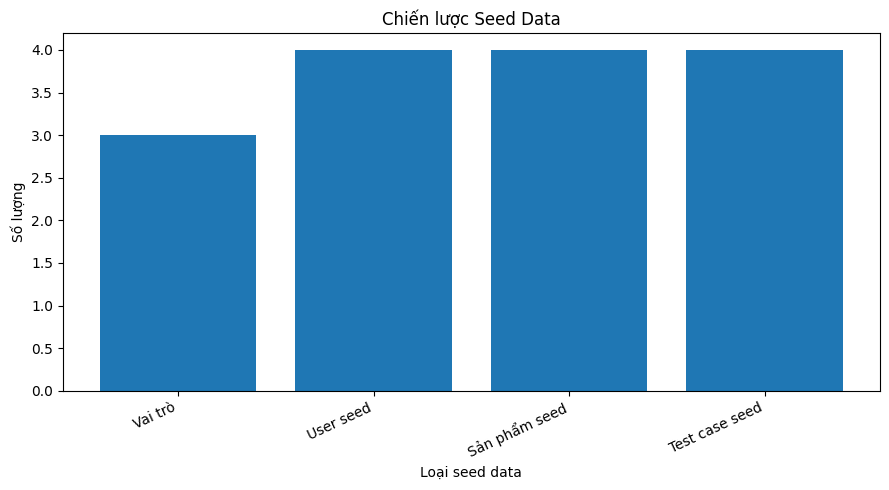

In [35]:
# Tạo seed data cố định cho roles, users, products, test_cases
seed_roles = pd.DataFrame([
    ["ROLE_ADMIN", "Quản trị viên", "Có toàn quyền quản lý hệ thống"],
    ["ROLE_STAFF", "Nhân viên", "Quản lý đơn hàng và khách hàng"],
    ["ROLE_CUSTOMER", "Khách hàng", "Sử dụng chức năng mua hàng"]
], columns=["ma_vai_tro", "ten_vai_tro", "mo_ta"])

seed_users = pd.DataFrame([
    ["U0001", "admin_test", "ROLE_ADMIN", "ACTIVE"],
    ["U0002", "staff_test", "ROLE_STAFF", "ACTIVE"],
    ["U0003", "customer_test", "ROLE_CUSTOMER", "ACTIVE"],
    ["U0004", "locked_customer", "ROLE_CUSTOMER", "LOCKED"]
], columns=["ma_user", "username", "ma_vai_tro", "trang_thai"])

seed_products = pd.DataFrame([
    ["SP_SEED_01", "Sản phẩm seed giá thấp", "Phụ kiện", 50000, "ACTIVE"],
    ["SP_SEED_02", "Sản phẩm seed giá trung bình", "Gia dụng", 500000, "ACTIVE"],
    ["SP_SEED_03", "Sản phẩm seed giá cao", "Laptop", 20000000, "ACTIVE"],
    ["SP_SEED_04", "Sản phẩm seed ngừng bán", "Điện thoại", 7000000, "INACTIVE"]
], columns=["ma_san_pham", "ten_san_pham", "danh_muc", "gia", "trang_thai"])

seed_test_cases = pd.DataFrame([
    ["TC-SEED-01", "Đăng nhập admin", "U0001", "Đăng nhập thành công"],
    ["TC-SEED-02", "Đăng nhập user bị khóa", "U0004", "Hệ thống từ chối đăng nhập"],
    ["TC-SEED-03", "Mua sản phẩm đang hoạt động", "SP_SEED_01", "Tạo đơn hàng thành công"],
    ["TC-SEED-04", "Mua sản phẩm ngừng bán", "SP_SEED_04", "Hệ thống từ chối mua hàng"]
], columns=["ma_test_case", "muc_dich", "du_lieu_seed", "ket_qua_mong_doi"])

# Lưu các seed ra CSV để dùng lại trong test
seed_roles.to_csv(DATA_DIR / "seed_roles.csv", index=False, encoding="utf-8-sig")
seed_users.to_csv(DATA_DIR / "seed_users.csv", index=False, encoding="utf-8-sig")
seed_products.to_csv(DATA_DIR / "seed_products.csv", index=False, encoding="utf-8-sig")
seed_test_cases.to_csv(DATA_DIR / "seed_test_cases.csv", index=False, encoding="utf-8-sig")

ket_qua_seed = pd.DataFrame([
    ["Vai trò", len(seed_roles), "Dữ liệu phân quyền nền tảng"],
    ["User seed", len(seed_users), "Tài khoản kiểm thử cố định"],
    ["Sản phẩm seed", len(seed_products), "Sản phẩm phục vụ kiểm thử mua hàng"],
    ["Test case seed", len(seed_test_cases), "Liên kết seed data với kịch bản kiểm thử"]
], columns=["loai_seed_data", "so_luong", "muc_dich_su_dung"])

xuat_csv(ket_qua_seed, "01_chien_luoc_seed_data.csv")
display(ket_qua_seed)

save_bar_chart(ket_qua_seed["loai_seed_data"], ket_qua_seed["so_luong"],
               "Chiến lược Seed Data", "Loại seed data", "Số lượng",
               "01_bieu_do_seed_data.png")

### Đánh giá Seed Data

Seed data giúp môi trường kiểm thử có dữ liệu nền ổn định. QA cần kiểm soát khả năng tái lập, tính đầy đủ của seed data và tránh việc seed data bị thay đổi ngoài ý muốn sau khi chạy test.

## 3. Synthetic User

Synthetic user là người dùng giả lập được sinh tự động để phục vụ kiểm thử mà không sử dụng dữ liệu cá nhân thật.

**Mục đích:** Sinh nhiều người dùng giả lập để kiểm thử tải, hành vi và kịch bản mà không dùng PII thật.

**Thuật toán:**
1. Lặp `i` từ 1 đến 500 và sinh `ma_synthetic_user` bằng `tao_ma('SU', i)`.
2. Sinh `ho_ten_gia_lap` bằng `random_name()` và `email_gia_lap` dưới dạng `synthetic_user_{i}@test.local`.
3. Sinh `so_dien_thoai_gia_lap`, `cccd_gia_lap`, `dia_chi_gia_lap`, `hang_thanh_vien`, `trang_thai`, `so_don_hang_gia_lap`, `tong_chi_tieu_gia_lap` ngẫu nhiên.
4. Gom các bản ghi vào list rồi chuyển sang `DataFrame`.
5. Lưu `DataFrame` ra CSV, tính tổng hợp theo `hang_thanh_vien` và vẽ biểu đồ phân bố.

,ma_synthetic_user,ho_ten_gia_lap,email_gia_lap,so_dien_thoai_gia_lap,cccd_gia_lap,dia_chi_gia_lap,hang_thanh_vien,trang_thai,so_don_hang_gia_lap,tong_chi_tieu_gia_lap
0,SU0001,Bùi Ngọc Thắng,synthetic_user_1@test.local,0803105968,SYN619585706,TP.HCM,Bronze,LOCKED,16,56463253
1,SU0002,Vũ Văn Tuấn,synthetic_user_2@test.local,0852873577,SYN601428284,Thái Nguyên,Bronze,ACTIVE,18,70134216
2,SU0003,Trần Thanh An,synthetic_user_3@test.local,0832841452,SYN556932551,TP.HCM,Platinum,ACTIVE,9,77531025
3,SU0004,Vũ Tiến Tuấn,synthetic_user_4@test.local,0818127915,SYN786603688,Đà Nẵng,Platinum,ACTIVE,2,35311610
4,SU0005,Phạm Anh Bình,synthetic_user_5@test.local,0867946290,SYN714089517,TP.HCM,Silver,ACTIVE,21,4840043


,hang_thanh_vien,so_luong_user
0,Bronze,119
1,Gold,116
2,Platinum,136
3,Silver,129


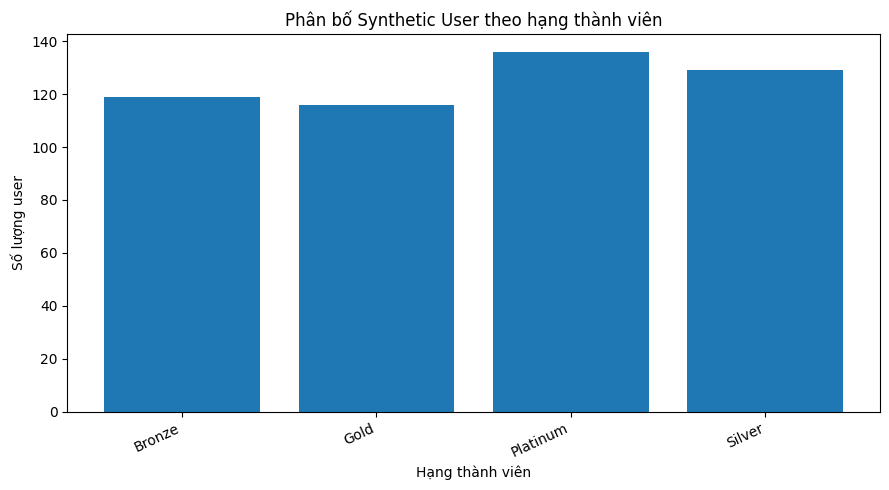

In [36]:
synthetic_users = []
for i in range(1, 501):
    name = random_name()
    synthetic_users.append([
        tao_ma("SU", i),
        name,
        f"synthetic_user_{i}@test.local",
        "08" + "".join(random.choices(string.digits, k=8)),
        "SYN" + "".join(random.choices(string.digits, k=9)),
        random.choice(tinh_thanh),
        random.choice(["Bronze", "Silver", "Gold", "Platinum"]),
        random.choice(["ACTIVE", "ACTIVE", "ACTIVE", "LOCKED"]),
        random.randint(0, 30),
        random.randint(0, 100000000)
    ])

synthetic_users = pd.DataFrame(synthetic_users, columns=[
    "ma_synthetic_user", "ho_ten_gia_lap", "email_gia_lap", "so_dien_thoai_gia_lap",
    "cccd_gia_lap", "dia_chi_gia_lap", "hang_thanh_vien", "trang_thai",
    "so_don_hang_gia_lap", "tong_chi_tieu_gia_lap"
])

synthetic_users.to_csv(DATA_DIR / "synthetic_users.csv", index=False, encoding="utf-8-sig")

summary_synthetic = synthetic_users.groupby("hang_thanh_vien").size().reset_index(name="so_luong_user")
xuat_csv(summary_synthetic, "02_tong_hop_synthetic_user.csv")

display(synthetic_users.head())
display(summary_synthetic)

save_bar_chart(summary_synthetic["hang_thanh_vien"], summary_synthetic["so_luong_user"],
               "Phân bố Synthetic User theo hạng thành viên", "Hạng thành viên", "Số lượng user",
               "02_bieu_do_synthetic_user.png")

In [37]:
# Kiểm tra chất lượng dữ liệu synthetic users (ngắn gọn)
quality_checks = pd.DataFrame([
    ["Không trùng email", synthetic_users["email_gia_lap"].is_unique],
    ["Không trùng số điện thoại", synthetic_users["so_dien_thoai_gia_lap"].is_unique],
    ["Không dùng email thật", synthetic_users["email_gia_lap"].str.endswith("@test.local").all()],
    ["Có nhiều trạng thái user", synthetic_users["trang_thai"].nunique() >= 2],
    ["Có nhiều hạng thành viên", synthetic_users["hang_thanh_vien"].nunique() >= 3]
], columns=["tieu_chi_kiem_tra", "ket_qua"])

quality_checks["danh_gia"] = quality_checks["ket_qua"].apply(lambda x: "ĐẠT" if x else "CHƯA ĐẠT")
xuat_csv(quality_checks, "02_kiem_tra_chat_luong_synthetic_user.csv")
display(quality_checks)

,tieu_chi_kiem_tra,ket_qua,danh_gia
0,Không trùng email,True,ĐẠT
1,Không trùng số điện thoại,True,ĐẠT
2,Không dùng email thật,True,ĐẠT
3,Có nhiều trạng thái user,True,ĐẠT
4,Có nhiều hạng thành viên,True,ĐẠT


### Đánh giá Synthetic User

Synthetic user giúp tạo dữ liệu đa dạng, có số lượng lớn và tránh dùng dữ liệu cá nhân thật. QA cần kiểm tra dữ liệu giả lập có đủ đa dạng, không trùng bất thường và không chứa PII thật.

## 4. Refresh dữ liệu kiểm thử

Refresh dữ liệu là quá trình làm mới database test từ nguồn dữ liệu khác. Quy trình an toàn nên là:

Production → Backup → Masking → Import vào Test → Kiểm tra toàn vẹn.

**Mục đích:** Lập kế hoạch các bước làm mới dữ liệu test một cách an toàn.

**Thuật toán:**
1. Xây `DataFrame` mô tả từng bước làm mới (backup, masking, import, validate, log).
2. Gán người phụ trách và mức độ bắt buộc cho từng bước.
3. Lưu `DataFrame` kế hoạch ra CSV và hiển thị để QA/DevOps tham khảo.

In [38]:
# Lập kế hoạch các bước làm mới dữ liệu test (tóm tắt)
refresh_plan = pd.DataFrame([
    [1, "Tạo bản sao production", "Backup dữ liệu hiện tại", "DBA", "BẮT BUỘC"],
    [2, "Ẩn danh dữ liệu nhạy cảm", "Mask email, số điện thoại, CCCD", "QA/Data Engineer", "BẮT BUỘC"],
    [3, "Nạp dữ liệu vào test", "Import dữ liệu đã xử lý", "DevOps", "BẮT BUỘC"],
    [4, "Kiểm tra toàn vẹn dữ liệu", "Đối chiếu khóa chính, khóa ngoại", "QA", "BẮT BUỘC"],
    [5, "Ghi log refresh", "Lưu thời gian refresh và người thực hiện", "QA Lead", "KHUYẾN NGHỊ"]
], columns=["buoc", "ten_buoc", "mo_ta", "nguoi_phu_trach", "muc_do"])

xuat_csv(refresh_plan, "03_ke_hoach_refresh_du_lieu.csv")
display(refresh_plan)

,buoc,ten_buoc,mo_ta,nguoi_phu_trach,muc_do
0,1,Tạo bản sao production,Backup dữ liệu hiện tại,DBA,BẮT BUỘC
1,2,Ẩn danh dữ liệu nhạy cảm,"Mask email, số điện thoại, CCCD",QA/Data Engineer,BẮT BUỘC
2,3,Nạp dữ liệu vào test,Import dữ liệu đã xử lý,DevOps,BẮT BUỘC
3,4,Kiểm tra toàn vẹn dữ liệu,"Đối chiếu khóa chính, khóa ngoại",QA,BẮT BUỘC
4,5,Ghi log refresh,Lưu thời gian refresh và người thực hiện,QA Lead,KHUYẾN NGHỊ


,noi_dung_kiem_tra,ket_qua,danh_gia
0,Đơn hàng tham chiếu khách hàng hợp lệ,True,ĐẠT
1,Chi tiết đơn hàng tham chiếu đơn hàng hợp lệ,True,ĐẠT
2,Chi tiết đơn hàng tham chiếu sản phẩm hợp lệ,True,ĐẠT
3,Thanh toán tham chiếu đơn hàng hợp lệ,True,ĐẠT


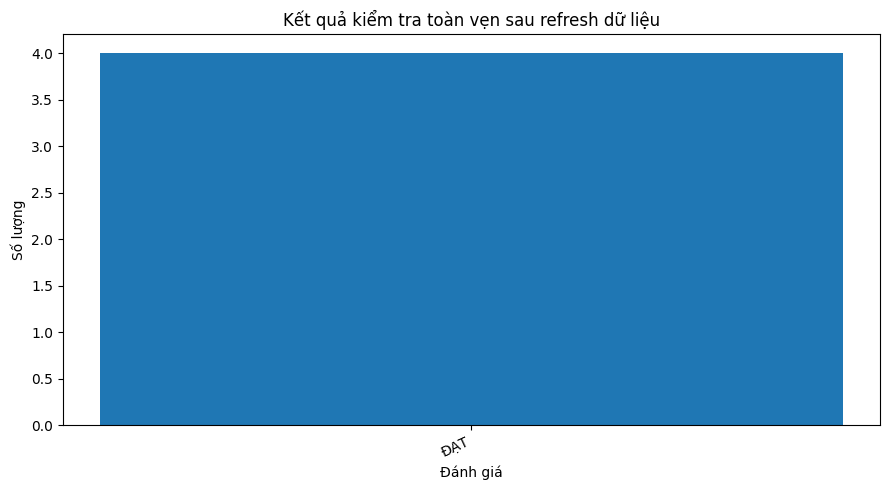

In [39]:
# Hàm kiểm tra toàn vẹn tham chiếu giữa các bảng (khóa chính/khóa ngoại)
def integrity_check(customers_df, orders_df, order_items_df, products_df, payments_df):
    return pd.DataFrame([
        ["Đơn hàng tham chiếu khách hàng hợp lệ", orders_df["ma_khach_hang"].isin(customers_df["ma_khach_hang"]).all()],
        ["Chi tiết đơn hàng tham chiếu đơn hàng hợp lệ", order_items_df["ma_don_hang"].isin(orders_df["ma_don_hang"]).all()],
        ["Chi tiết đơn hàng tham chiếu sản phẩm hợp lệ", order_items_df["ma_san_pham"].isin(products_df["ma_san_pham"]).all()],
        ["Thanh toán tham chiếu đơn hàng hợp lệ", payments_df["ma_don_hang"].isin(orders_df["ma_don_hang"]).all()],
    ], columns=["noi_dung_kiem_tra", "ket_qua"])

refresh_integrity = integrity_check(customers, orders, order_items, products, payments)
refresh_integrity["danh_gia"] = refresh_integrity["ket_qua"].apply(lambda x: "ĐẠT" if x else "CHƯA ĐẠT")

xuat_csv(refresh_integrity, "03_kiem_tra_toan_ven_refresh.csv")
display(refresh_integrity)

summary_refresh = refresh_integrity["danh_gia"].value_counts().reset_index()
summary_refresh.columns = ["danh_gia", "so_luong"]

save_bar_chart(summary_refresh["danh_gia"], summary_refresh["so_luong"],
               "Kết quả kiểm tra toàn vẹn sau refresh dữ liệu",
               "Đánh giá", "Số lượng", "03_bieu_do_refresh_du_lieu.png")

### Đánh giá Refresh dữ liệu

Refresh giúp môi trường test gần thực tế hơn, nhưng phải kiểm soát masking, tính toàn vẹn khóa chính/khóa ngoại, log refresh và tác động đến seed data.

## 5. Bảo vệ dữ liệu cá nhân

Dữ liệu kiểm thử không nên làm lộ PII như email, số điện thoại, CCCD, họ tên và địa chỉ. Phần này áp dụng masking/anonymization trước khi đưa dữ liệu vào môi trường test.

**Mục đích:** Ẩn danh và masking các trường nhạy cảm để giảm rủi ro rò rỉ PII.

**Thuật toán:**
1. Định nghĩa hàm `mask_email` để giữ 2 ký tự đầu và domain, hoặc trả về placeholder khi lỗi.
2. Định nghĩa `mask_phone` và `mask_cccd` để che các chữ số giữa, giữ prefix/suffix.
3. Định nghĩa `anonymize_name` để thay tên bằng một nhãn ẩn danh.
4. Tạo bản sao `customers.copy()`, áp dụng các hàm masking cho các cột tương ứng.
5. Lưu dữ liệu masked ra CSV và hiển thị so sánh trước/sau.

In [40]:
# Hàm masking/anonymize để bảo vệ PII trước khi import vào môi trường test
def mask_email(email):
    try:
        name, domain = email.split("@")
        return name[:2] + "***@" + domain
    except Exception:
        return "***@masked.local"

def mask_phone(phone):
    phone = str(phone)
    return phone[:3] + "****" + phone[-3:]

def mask_cccd(cccd):
    cccd = str(cccd)
    return cccd[:3] + "******" + cccd[-3:]

def anonymize_name(name):
    return "Khách hàng ẩn danh"

# Áp dụng masking cho bản sao customers để giữ nguyên dữ liệu gốc
masked_customers = customers.copy()
masked_customers["ho_ten"] = masked_customers["ho_ten"].apply(anonymize_name)
masked_customers["email"] = masked_customers["email"].apply(mask_email)
masked_customers["so_dien_thoai"] = masked_customers["so_dien_thoai"].apply(mask_phone)
masked_customers["cccd"] = masked_customers["cccd"].apply(mask_cccd)

masked_customers.to_csv(DATA_DIR / "test_customers_masked.csv", index=False, encoding="utf-8-sig")

print("Trước masking:")
display(customers.head())
print("Sau masking:")
display(masked_customers.head())

Trước masking:


,ma_khach_hang,ho_ten,email,so_dien_thoai,cccd,dia_chi,hang_thanh_vien,trang_thai
0,KH0001,Trần Văn Tuấn,trầnvăntuấn1@example.com,0922768040,250165258086,Vĩnh Phúc,Silver,ACTIVE
1,KH0002,Phạm Anh Bình,phạmanhbình2@example.com,0900868759,358685702202,Hà Nội,Silver,LOCKED
2,KH0003,Bùi Anh Chi,bùianhchi3@example.com,0932296617,139656872032,Thái Nguyên,Gold,LOCKED
3,KH0004,Phạm Hữu Lan,phạmhữulan4@example.com,0986117574,539147811653,TP.HCM,Silver,LOCKED
4,KH0005,Đỗ Văn Trang,đỗvăntrang5@example.com,0976526144,982519826617,TP.HCM,Gold,ACTIVE


Sau masking:


,ma_khach_hang,ho_ten,email,so_dien_thoai,cccd,dia_chi,hang_thanh_vien,trang_thai
0,KH0001,Khách hàng ẩn danh,tr***@example.com,092****040,250******086,Vĩnh Phúc,Silver,ACTIVE
1,KH0002,Khách hàng ẩn danh,ph***@example.com,090****759,358******202,Hà Nội,Silver,LOCKED
2,KH0003,Khách hàng ẩn danh,bù***@example.com,093****617,139******032,Thái Nguyên,Gold,LOCKED
3,KH0004,Khách hàng ẩn danh,ph***@example.com,098****574,539******653,TP.HCM,Silver,LOCKED
4,KH0005,Khách hàng ẩn danh,đỗ***@example.com,097****144,982******617,TP.HCM,Gold,ACTIVE


Trước masking:


,ma_khach_hang,ho_ten,email,so_dien_thoai,cccd,dia_chi,hang_thanh_vien,trang_thai
0,KH0001,Trần Văn Tuấn,trầnvăntuấn1@example.com,0922768040,250165258086,Vĩnh Phúc,Silver,ACTIVE
1,KH0002,Phạm Anh Bình,phạmanhbình2@example.com,0900868759,358685702202,Hà Nội,Silver,LOCKED
2,KH0003,Bùi Anh Chi,bùianhchi3@example.com,0932296617,139656872032,Thái Nguyên,Gold,LOCKED
3,KH0004,Phạm Hữu Lan,phạmhữulan4@example.com,0986117574,539147811653,TP.HCM,Silver,LOCKED
4,KH0005,Đỗ Văn Trang,đỗvăntrang5@example.com,0976526144,982519826617,TP.HCM,Gold,ACTIVE


Sau masking:


,ma_khach_hang,ho_ten,email,so_dien_thoai,cccd,dia_chi,hang_thanh_vien,trang_thai
0,KH0001,Khách hàng ẩn danh,tr***@masked.local,092****040,250******086,Vĩnh Phúc,Silver,ACTIVE
1,KH0002,Khách hàng ẩn danh,ph***@masked.local,090****759,358******202,Hà Nội,Silver,LOCKED
2,KH0003,Khách hàng ẩn danh,bù***@masked.local,093****617,139******032,Thái Nguyên,Gold,LOCKED
3,KH0004,Khách hàng ẩn danh,ph***@masked.local,098****574,539******653,TP.HCM,Silver,LOCKED
4,KH0005,Khách hàng ẩn danh,đỗ***@masked.local,097****144,982******617,TP.HCM,Gold,ACTIVE


,loai_du_lieu_nhay_cam,truoc_masking,sau_masking,muc_giam_rui_ro,danh_gia
0,Email thật,100,0,100,ĐẠT
1,Số điện thoại thật,100,0,100,ĐẠT
2,CCCD thật,100,0,100,ĐẠT


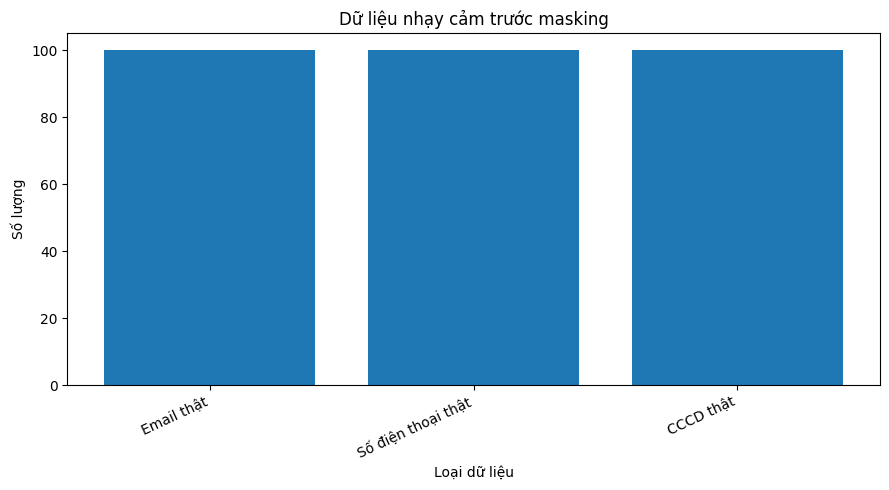

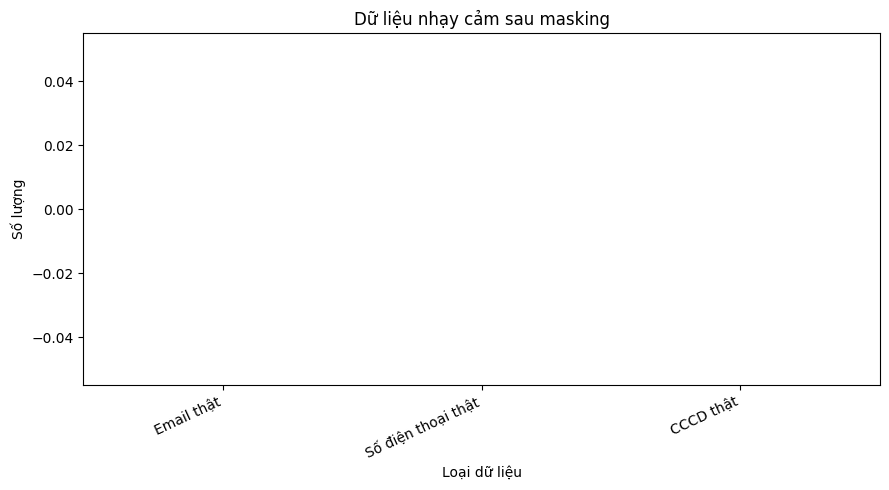

In [41]:
# =========================
# Bảo vệ dữ liệu cá nhân bằng masking
# =========================

def mask_email(email):
    try:
        name, domain = str(email).split("@")
        return name[:2] + "***@masked.local"
    except Exception:
        return "***@masked.local"

def mask_phone(phone):
    phone = str(phone)
    return phone[:3] + "****" + phone[-3:]

def mask_cccd(cccd):
    cccd = str(cccd)
    return cccd[:3] + "******" + cccd[-3:]

def anonymize_name(name):
    return "Khách hàng ẩn danh"


# Tạo bản dữ liệu đã masking từ dữ liệu customers gốc
masked_customers = customers.copy()

masked_customers["ho_ten"] = masked_customers["ho_ten"].apply(anonymize_name)
masked_customers["email"] = masked_customers["email"].apply(mask_email)
masked_customers["so_dien_thoai"] = masked_customers["so_dien_thoai"].apply(mask_phone)
masked_customers["cccd"] = masked_customers["cccd"].apply(mask_cccd)

# Lưu dữ liệu đã masking
masked_customers.to_csv(
    DATA_DIR / "test_customers_masked.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Trước masking:")
display(customers.head())

print("Sau masking:")
display(masked_customers.head())


# =========================
# Kiểm tra dữ liệu nhạy cảm trước/sau masking
# =========================

def count_unmasked_email(df):
    return df["email"].astype(str).str.contains("@example.com", regex=False).sum()

def count_unmasked_phone(df):
    return df["so_dien_thoai"].astype(str).str.match(r"^09\d{8}$").sum()

def count_unmasked_cccd(df):
    return df["cccd"].astype(str).str.match(r"^\d{12}$").sum()


privacy_report = pd.DataFrame([
    ["Email thật", count_unmasked_email(customers), count_unmasked_email(masked_customers)],
    ["Số điện thoại thật", count_unmasked_phone(customers), count_unmasked_phone(masked_customers)],
    ["CCCD thật", count_unmasked_cccd(customers), count_unmasked_cccd(masked_customers)],
], columns=[
    "loai_du_lieu_nhay_cam",
    "truoc_masking",
    "sau_masking"
])

privacy_report["muc_giam_rui_ro"] = (
    privacy_report["truoc_masking"] - privacy_report["sau_masking"]
)

privacy_report["danh_gia"] = privacy_report["sau_masking"].apply(
    lambda x: "ĐẠT" if x == 0 else "CÒN RỦI RO"
)

xuat_csv(privacy_report, "04_bao_ve_du_lieu_ca_nhan.csv")
display(privacy_report)


# =========================
# Biểu đồ trước/sau masking
# =========================

save_bar_chart(
    privacy_report["loai_du_lieu_nhay_cam"],
    privacy_report["truoc_masking"],
    "Dữ liệu nhạy cảm trước masking",
    "Loại dữ liệu",
    "Số lượng",
    "04a_bieu_do_truoc_masking.png"
)

save_bar_chart(
    privacy_report["loai_du_lieu_nhay_cam"],
    privacy_report["sau_masking"],
    "Dữ liệu nhạy cảm sau masking",
    "Loại dữ liệu",
    "Số lượng",
    "04b_bieu_do_sau_masking.png"
)

### Đánh giá bảo vệ dữ liệu cá nhân

Sau masking, email, số điện thoại và CCCD không còn ở dạng dữ liệu thật. QA cần kiểm tra dữ liệu nhạy cảm còn sót, đồng thời đảm bảo dữ liệu sau masking vẫn dùng được cho kiểm thử.

## 6. Chiến lược tổng hợp

Bảng sau tổng hợp chiến lược quản lý dữ liệu kiểm thử cho ứng dụng cơ sở dữ liệu.

**Mục đích:** Tổng hợp các chiến lược đã trình bày để làm tài liệu cho QA/DevOps.

**Thuật toán:**
1. Xây `DataFrame` `strategy` gồm các chiến lược, mục tiêu, cách thực hiện và điểm QA cần kiểm soát.
2. Lưu `DataFrame` ra CSV để làm tài liệu tham khảo cho QA/DevOps.
3. Hiển thị bảng tổng hợp trong notebook.

In [42]:
# Tổng hợp chiến lược quản lý dữ liệu kiểm thử (dùng làm tài liệu)
strategy = pd.DataFrame([
    ["Seed Data", "Tạo dữ liệu nền tảng ổn định", "Role, user test, sản phẩm seed", "QA kiểm tra khả năng tái lập"],
    ["Synthetic User", "Sinh người dùng giả lập", "500 synthetic users", "QA kiểm tra dữ liệu không trùng và không chứa PII thật"],
    ["Data Refresh", "Làm mới dữ liệu test", "Backup → Masking → Import → Validate", "QA kiểm tra toàn vẹn và log refresh"],
    ["Data Privacy", "Bảo vệ dữ liệu cá nhân", "Mask email, số điện thoại, CCCD", "QA kiểm tra dữ liệu nhạy cảm còn sót"],
], columns=["chien_luoc", "muc_tieu", "cach_thuc_thuc_hien", "diem_QA_can_kiem_soat"])

xuat_csv(strategy, "05_chien_luoc_quan_ly_du_lieu_kiem_thu.csv")
display(strategy)

,chien_luoc,muc_tieu,cach_thuc_thuc_hien,diem_QA_can_kiem_soat
0,Seed Data,Tạo dữ liệu nền tảng ổn định,"Role, user test, sản phẩm seed",QA kiểm tra khả năng tái lập
1,Synthetic User,Sinh người dùng giả lập,500 synthetic users,QA kiểm tra dữ liệu không trùng và không chứa PII thật
2,Data Refresh,Làm mới dữ liệu test,Backup → Masking → Import → Validate,QA kiểm tra toàn vẹn và log refresh
3,Data Privacy,Bảo vệ dữ liệu cá nhân,"Mask email, số điện thoại, CCCD",QA kiểm tra dữ liệu nhạy cảm còn sót


## 7. Kết luận

Notebook đã minh họa một chiến lược quản lý dữ liệu kiểm thử gồm seed data, synthetic user, refresh dữ liệu và bảo vệ dữ liệu cá nhân. Kết quả cho thấy dữ liệu kiểm thử cần được thiết kế có mục đích, có khả năng tái lập, đủ bao phủ nghiệp vụ và không làm lộ thông tin cá nhân.

In [43]:
# In danh sách file kết quả trong thư mục outputs_notebook
print("HOÀN THÀNH NOTEBOOK!")
print("Dữ liệu đầu vào: data/")
print("Kết quả đầu ra: outputs_notebook/")
print("Các file kết quả:")
for file in sorted(OUTPUT_DIR.glob("*.csv")):
    print("-", file.name)

HOÀN THÀNH NOTEBOOK!
Dữ liệu đầu vào: data/
Kết quả đầu ra: outputs_notebook/
Các file kết quả:
- 01_chien_luoc_seed_data.csv
- 02_kiem_tra_chat_luong_synthetic_user.csv
- 02_tong_hop_synthetic_user.csv
- 03_ke_hoach_refresh_du_lieu.csv
- 03_kiem_tra_toan_ven_refresh.csv
- 04_bao_ve_du_lieu_ca_nhan.csv
- 05_chien_luoc_quan_ly_du_lieu_kiem_thu.csv
